#Importing libraries and cleaned_df_Eg dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [4]:
warnings.filterwarnings("ignore")
df=pd.read_csv('polymorph.csv')
pd.set_option('display.max_columns', None)
df.head(2)

,formula,material_id,functional,band_gap,gap_AO,max_metallic_valence,HOMO_energy,range_metallic_valence,avg_metallic_valence,max_Density_(g/mL),range_Number_of_unfilled_d_valence_electrons,avg_Density_(g/mL),dev_Mulliken_EN,max_Mulliken_EN,frac p valence electrons,avg_outer_shell_electrons,max_number_of_valence_electrons,max_families,mode_heat_atomization(kJ/mol),avg p valence electrons,frac d valence electrons,avg_number_of_valence_electrons,LUMO_energy,dev_Pauling_Electronegativity,avg_heat_atomization(kJ/mol),avg_Number_of_unfilled_d_valence_electrons,mode_Mendeleev_Number,max_gilmor_number_of_valence_electron,max_l_quantum_number,max_1st_ionization_potential_(kJ/mol),avg_heat_of_vaporization_(kJ/mol)_,max ionic char,min_specific_heat_(J/g_K)_,avg_l_quantum_number,avg_Mulliken_EN,range_1st_ionization_potential_(kJ/mol),dev_gilmor_number_of_valence_electron,max_heat_of_vaporization_(kJ/mol)_,range_number_of_valence_electrons,range_valence_p,avg_Nonmetal,mode_outer_shell_electrons,range_families,avg_Melting_point_(K),range_gilmor_number_of_valence_electron,range_l_quantum_number,dev_Mendeleev_Number,range_MB_electonegativity,mode_Pauling_Electronegativity,avg_Metal,max_Atomic_Number,range_group,dev_Period,dev_Cohesive_energy,dev_Boiling_Point_(K),dev_Atomic_Number,frac s valence electrons,mode_metallic_valence,mode_number_of_valence_electrons,mode_crystal_radius,dev_group,avg_crystal_radius,dev_Nonmetal,mode_Miracle_Radius_[pm],max_Melting_point_(K),avg_families,range_Period,min_Allred-Rockow_electronegativity,min_number_of_valence_electrons,max_thermal_conductivity_(W/(m_K))_,dev_number_of_valence_electrons,range_Gordy_electonegativity,avg_Atomic_Weight,dev_Metal,band center,avg_Miracle_Radius_[pm],avg_Gordy_electonegativity,dev_polarizability(A^3),min_Cohesive_energy,avg_MB_electonegativity,min_gilmor_number_of_valence_electron,range_outer_shell_electrons,min_Boiling_Point_(K),mode_group,min_Density_(g/mL),min_Mulliken_EN,min_Miracle_Radius_[pm],avg_valence_s,dev_l_quantum_number,max_group,dev_ionic_radius,range_Atomic_Radius,min_MB_electonegativity,min_l_quantum_number,avg_gilmor_number_of_valence_electron,dev_Number_of_unfilled_s_valence_electrons,min_crystal_radius,max_crystal_radius,range_ionic_radius,mode_Density_(g/mL),mode_heat_of_vaporization_(kJ/mol)_,min_1st_ionization_potential_(kJ/mol),max_ionic_radius,min_outer_shell_electrons,mode_thermal_conductivity_(W/(m_K))_,mode_Number_of_unfilled_f_valence_electrons,min_Number_of_unfilled_f_valence_electrons,mode_l_quantum_number,max_Nonmetal,avg_specific_heat_(J/g_K)_,min_thermal_conductivity_(W/(m_K))_,max_specific_heat_(J/g_K)_,mode_Atomic_Radius,avg_Mendeleev_Number,avg_heat_of_fusion_(kJ/mol)_,min_heat_of_fusion_(kJ/mol)_,max_Miracle_Radius_[pm],dev_Number_of_unfilled_p_valence_electrons,dev_Atomic_Radius,avg_Zunger_radii_sum,min_Gordy_electonegativity,dev_crystal_radius,min_Atomic_Weight,min_Metal,mode_Number_of_unfilled_s_valence_electrons,min_Nonmetal,dev_Miracle_Radius_[pm],avg_group,range_Metal,min_ionic_radius,avg_Covalent_Radius,range_Nonmetal,max_Number_of_unfilled_p_valence_electrons,min_valence_d,dev_heat_of_fusion_(kJ/mol)_,range_crystal_radius,dev_Metalliod,range_Zunger_radii_sum,range_Miracle_Radius_[pm],mode_Number_of_unfilled_d_valence_electrons,dev_outer_shell_electrons,a_site_radius,b_site_radius,x_site_radius,Tolerance_factor,Octahedral_factor,spacegroup_num,crystal_system_int,n_symmetry_ops,density,vpa,packing fraction,max packing efficiency,GII
0,CaHfS3,mp-1190098,GGA Static,1.5238,0.095211,4.00,-0.261676,2.00,2.400,13.30,2.0,4.212000,1.5456,6.22,0.315789,4.4,6.0,7.0,279.0,2.4,0.052632,4.8,-0.166465,0.6864,326.8,9.6,88.0,6.0,2.0,1000.0,151.54000,0.464257,0.140,1.0,4.932,410.0,1.92,575.0,4.0,4.0,0.6,6.0,5.0,954.03,4.0,2.0,29.76,1.48,2.58,0.4,72.0,14.0,0.96,1.2296,1246.704,17.6,0.263158,2.0,6.0,0.43,6.24,0.656,0.48,103.0,2500.15,5.4,3.0,1.034,2.0,200.0,1.44,3.3576,62.95320,0.48,4.78801,133.6,5.38412,7.96800,1.84,2.170,2.0,4.0,717.85,16.0,1.55000,2.

In [5]:
print(df.shape)

(2344, 154)


#Polymorphs

In [6]:
FORMULA_COL = "formula"        # reduced/pretty formula string
TARGET_COL = "band_gap"        # your target column
ID_COL = "material_id"
RANDOM_STATE = 42
SINGLETON_TEST_SIZE = 0.15     # test-set fraction for NON-polymorphic entries


# ============================================================
# PART 1: Polymorph identification and analysis
# ============================================================
formula_counts = df.groupby(FORMULA_COL)[ID_COL].count()

df["n_polymorphs_for_formula"] = df[FORMULA_COL].map(formula_counts)
df["is_polymorphic"] = df["n_polymorphs_for_formula"] > 1

n_total = len(df)
n_unique_compositions = formula_counts.shape[0]
polymorphic_formulas = formula_counts[formula_counts > 1]
n_polymorphic_groups = polymorphic_formulas.shape[0]
n_polymorphic_entries = df["is_polymorphic"].sum()
n_singleton_entries = n_total - n_polymorphic_entries

print("=" * 55)
print("POLYMORPH SUMMARY")
print("=" * 55)
print(f"Total entries                          : {n_total}")
print(f"Unique reduced compositions             : {n_unique_compositions}")
print(f"Compositions with a single structure    : {n_unique_compositions - n_polymorphic_groups}")
print(f"Compositions with >=2 structures (polymorphic groups): {n_polymorphic_groups}")
print(f"Total entries belonging to polymorphic groups : {n_polymorphic_entries} "
      f"({100*n_polymorphic_entries/n_total:.1f}% of dataset)")
print(f"Total singleton (non-polymorphic) entries     : {n_singleton_entries}")

# ---- distribution of polymorph-group sizes ----
group_size_counts = polymorphic_formulas.value_counts().sort_index()
print("\nDistribution of polymorph group sizes (size -> number of compositions):")
print(group_size_counts)

POLYMORPH SUMMARY
Total entries                          : 2344
Unique reduced compositions             : 1443
Compositions with a single structure    : 1026
Compositions with >=2 structures (polymorphic groups): 417
Total entries belonging to polymorphic groups : 1318 (56.2% of dataset)
Total singleton (non-polymorphic) entries     : 1026

Distribution of polymorph group sizes (size -> number of compositions):
material_id
2     224
3      88
4      52
5      16
6      14
7      10
8       2
9       4
10      2
11      1
13      1
20      2
28      1
Name: count, dtype: int64


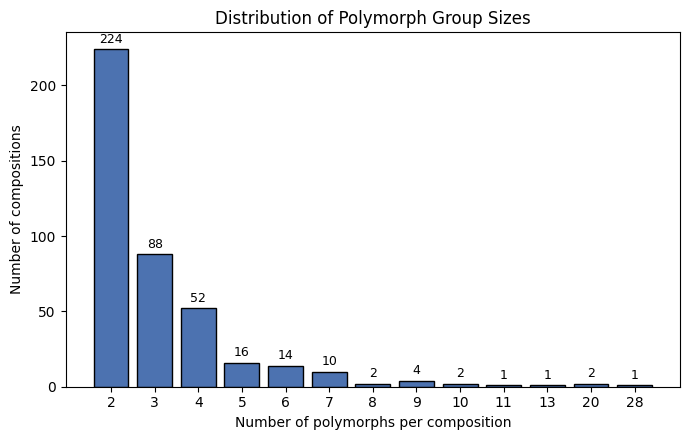

In [7]:
# ============================================================
# PLOT 1: Bar plot -- number of compositions by polymorph
# group size
# ============================================================
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(group_size_counts.index.astype(str), group_size_counts.values,
       color="#4C72B0", edgecolor="black")
ax.set_xlabel("Number of polymorphs per composition")
ax.set_ylabel("Number of compositions")
ax.set_title("Distribution of Polymorph Group Sizes")
for i, v in enumerate(group_size_counts.values):
    ax.text(i, v + max(group_size_counts.values) * 0.01, str(v),
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("polymorph_group_size_distribution.png", dpi=300)
plt.show()

In [8]:
# ============================================================
# PART 2: Bandgap spread within polymorphic groups
# ============================================================
def compute_group_spread(group):
    return pd.Series({
        "n_polymorphs": len(group),
        "bg_min": group[TARGET_COL].min(),
        "bg_max": group[TARGET_COL].max(),
        "bg_spread": group[TARGET_COL].max() - group[TARGET_COL].min(),
        "bg_mean": group[TARGET_COL].mean(),
        "bg_std": group[TARGET_COL].std()
    })

poly_only = df[df["is_polymorphic"]]
spread_df = poly_only.groupby(FORMULA_COL).apply(compute_group_spread).reset_index()
spread_df = spread_df.rename(columns={FORMULA_COL: "formula"})

print("\n" + "=" * 55)
print("BANDGAP SPREAD WITHIN POLYMORPHIC GROUPS")
print("=" * 55)
print(f"Mean spread   : {spread_df['bg_spread'].mean():.3f} eV")
print(f"Median spread : {spread_df['bg_spread'].median():.3f} eV")
print(f"Max spread    : {spread_df['bg_spread'].max():.3f} eV")
print(f"Min spread    : {spread_df['bg_spread'].min():.3f} eV")

print("\nTop 10 compositions by bandgap spread:")
print(spread_df.sort_values("bg_spread", ascending=False).head(10)
      [["formula", "n_polymorphs", "bg_min", "bg_max", "bg_spread"]])



BANDGAP SPREAD WITHIN POLYMORPHIC GROUPS
Mean spread   : 1.035 eV
Median spread : 0.729 eV
Max spread    : 6.314 eV
Min spread    : 0.000 eV

Top 10 compositions by bandgap spread:
    formula  n_polymorphs  bg_min  bg_max  bg_spread
242  NaClO3           5.0  0.0000  6.3141     6.3141
342  SrZrO3          10.0  0.0000  5.3771     5.3771
225  MgSiO3           9.0  0.4428  5.7959     5.3531
406   YbBO3           3.0  0.0000  5.1482     5.1482
251  NaNiF3           2.0  0.0000  5.1242     5.1242
288  RbMgF3           2.0  2.2027  6.9351     4.7324
198  LiMnF3          13.0  0.0000  4.4900     4.4900
240  NaBrO3           3.0  0.0000  4.4812     4.4812
174    KPO3           4.0  0.7700  5.0422     4.2722
328  SrGeO3           2.0  0.0000  4.1981     4.1981


In [9]:
TARGET_COL = "band_gap"

# ------------------------------------------------------------
# BG Distribution statistics
# ------------------------------------------------------------
n_total = len(df)
n_zero = (df[TARGET_COL] == 0).sum()
frac_zero = 100 * n_zero / n_total

print("=" * 55)
print("BANDGAP DISTRIBUTION SUMMARY")
print("=" * 55)
print(f"Total entries        : {n_total}")
print(f"Entries with Eg = 0   : {n_zero} ({frac_zero:.2f}%)")
print(f"Entries with Eg > 0   : {n_total - n_zero} ({100 - frac_zero:.2f}%)")
print(f"Mean bandgap          : {df[TARGET_COL].mean():.3f} eV")
print(f"Median bandgap        : {df[TARGET_COL].median():.3f} eV")
print(f"Min / Max bandgap     : {df[TARGET_COL].min():.3f} / {df[TARGET_COL].max():.3f} eV")
print(f"Std dev               : {df[TARGET_COL].std():.3f} eV")

BANDGAP DISTRIBUTION SUMMARY
Total entries        : 2344
Entries with Eg = 0   : 1151 (49.10%)
Entries with Eg > 0   : 1193 (50.90%)
Mean bandgap          : 1.166 eV
Median bandgap        : 0.057 eV
Min / Max bandgap     : 0.000 / 6.954 eV
Std dev               : 1.587 eV


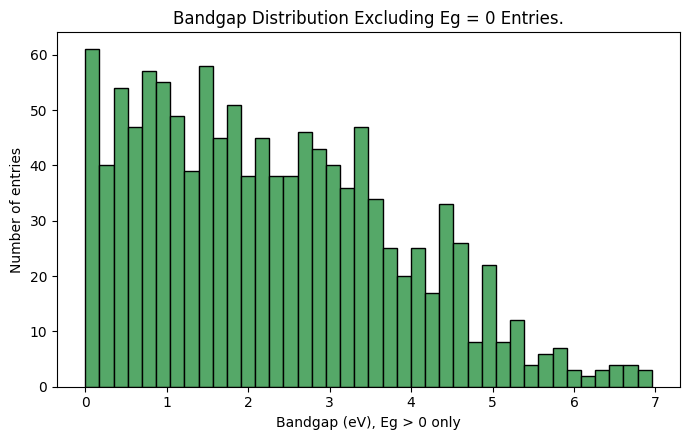

In [10]:
# ------------------------------------------------------------
# PLOT: Zoomed view excluding zero-gap entries, to see the
# shape of the non-metallic distribution clearly
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))
nonzero = df.loc[df[TARGET_COL] > 0, TARGET_COL]
ax.hist(nonzero, bins=40, color="#55A868", edgecolor="black")
ax.set_xlabel("Bandgap (eV), Eg > 0 only")
ax.set_ylabel("Number of entries")
ax.set_title(f"Bandgap Distribution Excluding Eg = 0 Entries.")
plt.tight_layout()
plt.savefig("nonzero_bandgap_distribution.png", dpi=300)
plt.show()

In [11]:
# 2,344-entry functional calculation
final_material_ids = set(df["material_id"].astype(str))

final_functional_counts = (
    df["functional"]
    .loc[df["material_id"].astype(str).isin(final_material_ids)]
    .value_counts(dropna=False)
)
print(final_functional_counts)
print((100 * final_functional_counts / final_functional_counts.sum()).round(1))

functional
GGA Static       1643
GGA+U Static      576
r2SCAN Static      61
NaN                43
PBEsol Static      21
Name: count, dtype: int64
functional
GGA Static       70.1
GGA+U Static     24.6
r2SCAN Static     2.6
NaN               1.8
PBEsol Static     0.9
Name: count, dtype: float64


TOP 10 COMPOSITIONS BY POLYMORPH COUNT
formula  n_polymorphs  bg_min   bg_max  bg_spread  bg_mean   bg_std
 CaSnS3            28  0.0000 1.876700   1.876700 0.467283 0.557470
 NaNbO3            20  1.5312 3.837700   2.306500 2.048895 0.581814
 LaMnO3            20  0.0000 1.692884   1.692884 0.352473 0.551987
 LiMnF3            13  0.0000 4.490000   4.490000 3.219908 1.078087
 LaCoO3            11  0.0000 1.001400   1.001400 0.481618 0.430742
 SrZrO3            10  0.0000 5.377100   5.377100 3.242210 1.308302
 CaSiO3            10  2.9075 6.580000   3.672500 3.817954 0.997445
 LiFeF3             9  2.2218 4.254400   2.032600 3.216400 0.549403
 MgSiO3             9  0.4428 5.795900   5.353100 3.842189 1.739591
  KMnF3             9  1.7405 3.359102   1.618602 2.554800 0.521222


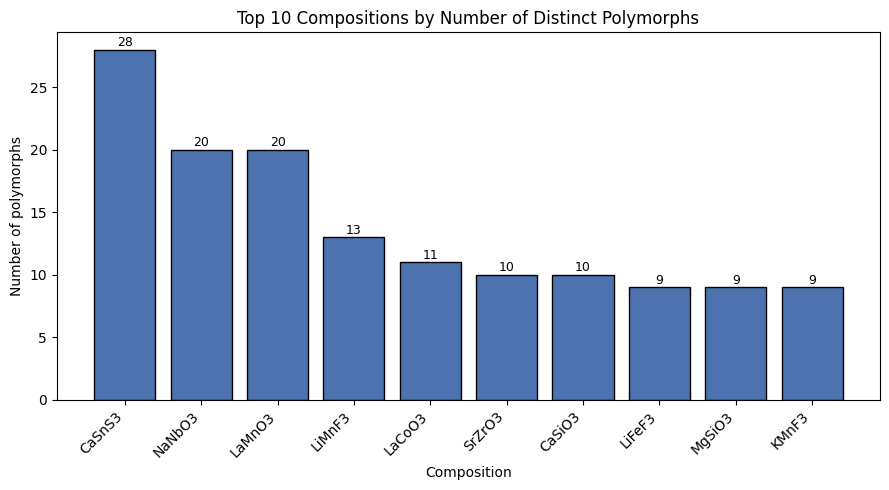

In [12]:
# ============================================================
# TOP 10 COMPOSITIONS BY POLYMORPH COUNT
# ============================================================

def compute_group_stats(group):
    return pd.Series({
        "n_polymorphs": len(group),
        "bg_min": group[TARGET_COL].min(),
        "bg_max": group[TARGET_COL].max(),
        "bg_spread": group[TARGET_COL].max() - group[TARGET_COL].min(),
        "bg_mean": group[TARGET_COL].mean(),
        "bg_std": group[TARGET_COL].std(),
        "material_ids": list(group[ID_COL])
    })

poly_only = df[df["is_polymorphic"]]
spread_df = poly_only.groupby(FORMULA_COL).apply(compute_group_stats).reset_index()
spread_df = spread_df.rename(columns={FORMULA_COL: "formula"})


top10_by_count = spread_df.sort_values("n_polymorphs", ascending=False).head(10)

print("=" * 70)
print("TOP 10 COMPOSITIONS BY POLYMORPH COUNT")
print("=" * 70)
print(top10_by_count[["formula", "n_polymorphs", "bg_min", "bg_max",
                       "bg_spread", "bg_mean", "bg_std"]].to_string(index=False))

# ---- bar plot: top 10 formulas by number of polymorphs ----
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(top10_by_count["formula"], top10_by_count["n_polymorphs"],
              color="#4C72B0", edgecolor="black")
ax.set_xlabel("Composition")
ax.set_ylabel("Number of polymorphs")
ax.set_title("Top 10 Compositions by Number of Distinct Polymorphs")
plt.xticks(rotation=45, ha="right")
for bar, val in zip(bars, top10_by_count["n_polymorphs"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05, str(val),
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("top10_polymorph_count.png", dpi=300)
plt.show()

In [13]:
# ============================================================
# PART H: Summary table for polymorphs
# ============================================================
summary_stats = {
    "Total entries": n_total,
    "Unique compositions": n_unique_compositions,
    "Polymorphic compositions (>=2 structures)": n_polymorphic_groups,
    "Total entries in polymorphic groups": int(n_polymorphic_entries),
    "% of dataset that is polymorphic": round(100 * n_polymorphic_entries / n_total, 2),
    "Largest polymorph group size": int(spread_df["n_polymorphs"].max()),
    "Mean bandgap spread (polymorphic groups)": round(spread_df["bg_spread"].mean(), 3),
    "Median bandgap spread": round(spread_df["bg_spread"].median(), 3),
    "Max bandgap spread": round(spread_df["bg_spread"].max(), 3),
}

summary_table = pd.DataFrame(list(summary_stats.items()), columns=["Metric", "Value"])
print("\n" + "=" * 70)
print("SUMMARY TABLE (for manuscript / reviewer response)")
print("=" * 70)
print(summary_table.to_string(index=False))

summary_table.to_csv("polymorph_analysis_summary.csv", index=False)
spread_df.sort_values("n_polymorphs", ascending=False).to_csv(
    "polymorph_groups_full.csv", index=False)


SUMMARY TABLE (for manuscript / reviewer response)
                                   Metric    Value
                            Total entries 2344.000
                      Unique compositions 1443.000
Polymorphic compositions (>=2 structures)  417.000
      Total entries in polymorphic groups 1318.000
         % of dataset that is polymorphic   56.230
             Largest polymorph group size   28.000
 Mean bandgap spread (polymorphic groups)    1.035
                    Median bandgap spread    0.729
                       Max bandgap spread    6.314


In [14]:
import numpy as np
import pandas as pd
#DATA SPLIT FOR POLYMORPH ANALYSIS

RANDOM_STATE = 42
POLY_TRAIN_FRACTION = 0.80   # ~80% of each polymorphic group's structures go to train

rng = np.random.RandomState(RANDOM_STATE)

train_idx_list = []
test_idx_list = []
held_out_poly_flag = pd.Series(False, index=df.index)

for formula, group in df[df["is_polymorphic"]].groupby(FORMULA_COL):
    idx = group.index.tolist()
    n = len(idx)
    rng.shuffle(idx)

    if n == 2:
        # can't meaningfully do 80/20 on 2 items -- 1 train / 1 test
        n_train = 1
    else:
        n_train = max(1, int(round(n * POLY_TRAIN_FRACTION)))
        n_train = min(n_train, n - 1)  # keep at least 1 in test

    train_ids = idx[:n_train]
    test_ids = idx[n_train:]

    train_idx_list.extend(train_ids)
    test_idx_list.extend(test_ids)
    held_out_poly_flag.loc[test_ids] = True

# --- ALL singleton (non-polymorphic) entries go to train, none held out ---
singleton_df = df[~df["is_polymorphic"]]
train_idx_list.extend(singleton_df.index.tolist())
# no singleton indices added to test_idx_list at all

# --- assemble final split ---
df["split"] = None
df.loc[train_idx_list, "split"] = "train"
df.loc[test_idx_list, "split"] = "test"
df["is_held_out_polymorph"] = held_out_poly_flag

train_df = df[df["split"] == "train"].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)

print(f"Train set size : {len(train_df)}  ({100*len(train_df)/len(df):.1f}% of dataset)")
print(f"  - polymorphic structures in train : {train_df['is_polymorphic'].sum()}")
print(f"  - singleton structures in train   : {(~train_df['is_polymorphic']).sum()}")
print(f"Test set size  : {len(test_df)}  ({100*len(test_df)/len(df):.1f}% of dataset)")
print(f"  - held-out polymorph rows in test : {test_df['is_held_out_polymorph'].sum()} "
      f"(should equal len(test_df) -- test set is 100% held-out polymorphs)")

# sanity checks
assert (test_df["is_held_out_polymorph"]).all(), \
    "Test set should contain ONLY held-out polymorph rows!"
assert (~test_df["is_polymorphic"]).sum() == 0, \
    "No singleton rows should be in the test set!"

check = df[df["is_polymorphic"]].groupby(FORMULA_COL)["split"].value_counts().unstack(fill_value=0)
assert (check.get("train", 0) >= 1).all(), "Some polymorphic group has 0 train representatives!"
assert (check.get("test", 0) >= 1).all(), "Some polymorphic group has 0 test representatives!"

print("\nSanity checks passed: test set is exclusively held-out polymorphs; "
      "every polymorphic composition has >=1 structure in both train and test.")

Train set size : 1905  (81.3% of dataset)
  - polymorphic structures in train : 879
  - singleton structures in train   : 1026
Test set size  : 439  (18.7% of dataset)
  - held-out polymorph rows in test : 439 (should equal len(test_df) -- test set is 100% held-out polymorphs)

Sanity checks passed: test set is exclusively held-out polymorphs; every polymorphic composition has >=1 structure in both train and test.


#Data Prep

In [16]:
# ============================================================
# Use the train/test split already created in df["split"]
# (one representative per polymorphic composition -> train,
# remaining polymorphs + singleton split -> test)
# ============================================================
import json

train_df = df[df["split"] == "train"].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)

print(f"Train set size : {len(train_df)}")
print(f"Test set size  : {len(test_df)}")
print(f"  - held-out polymorph rows in test : {test_df['is_held_out_polymorph'].sum()}")
print(f"  - singleton rows in test          : {(~test_df['is_held_out_polymorph']).sum()}")

# ============================================================
# Feature-set column lists -- from column_groups.json, NOT
# positional slicing. This avoids the exact problem the slice-
# index approach warns about: helper columns like
# n_polymorphs_for_formula, is_polymorphic, split,
# is_held_out_polymorph shift column positions, silently
# breaking iloc-based slices without any error being raised.
# ============================================================
with open("column_groups.json") as f:
    column_groups = json.load(f)

elemental_cols = column_groups["elemental"]
geometrical_cols = column_groups["geometrical"]
structural_cols = column_groups["structural"]

print(f"Elemental columns   : {len(elemental_cols)}")
print(f"Geometrical columns : {len(geometrical_cols)}")
print(f"Structural columns  : {len(structural_cols)}")

# Sanity check: confirm every listed column actually exists in
# both train_df and test_df -- catches a stale/mismatched JSON
# immediately instead of a silent KeyError deep in the code below.
all_listed = elemental_cols + geometrical_cols + structural_cols
missing_in_train = [c for c in all_listed if c not in train_df.columns]
missing_in_test = [c for c in all_listed if c not in test_df.columns]
if missing_in_train or missing_in_test:
    raise ValueError(
        f"column_groups.json does not match df. "
        f"Missing in train_df: {missing_in_train}. "
        f"Missing in test_df: {missing_in_test}. "
        f"Re-run Script 1 on the current df to regenerate a matching JSON."
    )

# ------------------------------------------------------------
# Progressive feature-set column lists
#   1 = Elemental only
#   2 = Elemental + Geometrical
#   3 = Elemental + Geometrical + Structural
# ------------------------------------------------------------
cols_set1 = elemental_cols
cols_set2 = elemental_cols + geometrical_cols
cols_set3 = elemental_cols + geometrical_cols + structural_cols

X_train1 = train_df[cols_set1].values
X_train2 = train_df[cols_set2].values
X_train3 = train_df[cols_set3].values

X_test1 = test_df[cols_set1].values
X_test2 = test_df[cols_set2].values
X_test3 = test_df[cols_set3].values

y_train = train_df["band_gap"].values.reshape(-1, 1)
y_test = test_df["band_gap"].values.reshape(-1, 1)

# also keep the held-out-polymorph mask aligned with the test arrays
held_out_mask_test = test_df["is_held_out_polymorph"].values

print(f"\nX_train1/X_test1: {X_train1.shape} / {X_test1.shape}")
print(f"X_train2/X_test2: {X_train2.shape} / {X_test2.shape}")
print(f"X_train3/X_test3: {X_train3.shape} / {X_test3.shape}")

Train set size : 1905
Test set size  : 439
  - held-out polymorph rows in test : 439
  - singleton rows in test          : 0
Elemental columns   : 137
Geometrical columns : 5
Structural columns  : 8

X_train1/X_test1: (1905, 137) / (439, 137)
X_train2/X_test2: (1905, 142) / (439, 142)
X_train3/X_test3: (1905, 150) / (439, 150)


#Model Training and Prediction on held out Polymorphic set

In [18]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [19]:
from sklearn.model_selection import KFold, cross_val_score
from catboost import CatBoostRegressor
# ============================================================
# Train three progressively-enriched CatBoost models
# (replace the CatBoostRegressor params below with your actual
# optimised hyperparameters from the original CB3 tuning --
# these are placeholders)
# ============================================================
def make_catboost_model(random_state=42):
    return CatBoostRegressor(
    iterations=984,
    depth=9,
    learning_rate=0.02423057754481626,
    l2_leaf_reg=4.411899015361824,
    bagging_temperature=0.3302865260909996,
    random_strength=3.758643425296768e-09,
    border_count=63,
    od_type='IncToDec',
    od_wait=48,
    random_seed=42
    )

CB3_optimised1 = make_catboost_model()
CB3_optimised2 = make_catboost_model()
CB3_optimised3 = make_catboost_model()

CB3_optimised1.fit(X_train1, y_train.ravel())
CB3_optimised2.fit(X_train2, y_train.ravel())
CB3_optimised3.fit(X_train3, y_train.ravel())


0:	learn: 1.5488403	total: 520ms	remaining: 8m 31s
1:	learn: 1.5281499	total: 630ms	remaining: 5m 9s
2:	learn: 1.5081595	total: 690ms	remaining: 3m 45s
3:	learn: 1.4877049	total: 779ms	remaining: 3m 10s
4:	learn: 1.4679826	total: 857ms	remaining: 2m 47s
5:	learn: 1.4482930	total: 930ms	remaining: 2m 31s
6:	learn: 1.4291482	total: 1.01s	remaining: 2m 21s
7:	learn: 1.4092682	total: 1.11s	remaining: 2m 16s
8:	learn: 1.3904957	total: 1.23s	remaining: 2m 12s
9:	learn: 1.3730632	total: 1.3s	remaining: 2m 6s
10:	learn: 1.3563703	total: 1.39s	remaining: 2m 3s
11:	learn: 1.3404949	total: 1.58s	remaining: 2m 8s
12:	learn: 1.3241311	total: 1.74s	remaining: 2m 10s
13:	learn: 1.3085435	total: 1.84s	remaining: 2m 7s
14:	learn: 1.2929990	total: 1.96s	remaining: 2m 6s
15:	learn: 1.2768415	total: 2.08s	remaining: 2m 6s
16:	learn: 1.2616744	total: 2.2s	remaining: 2m 5s
17:	learn: 1.2464541	total: 2.29s	remaining: 2m 3s
18:	learn: 1.2329166	total: 2.41s	remaining: 2m 2s
19:	learn: 1.2185214	total: 2.51s	

CatBoostRegressor(bagging_temperature=0.3302865260909996, border_count=63, depth=9, iterations=984, l2_leaf_reg=4.411899015361824, learning_rate=0.02423057754481626, loss_function='RMSE', od_type='IncToDec', od_wait=48, random_seed=42, random_strength=3.758643425296768e-09)

In [20]:
# ============================================================
# Validation: Held-out Polymorphs Only
# ============================================================

def evaluate(model, X_test, y_test, held_out_mask, label):
    y_pred = np.maximum(model.predict(X_test), 0)

    rows = []

    if held_out_mask.sum() > 0:
        yp, yt = y_pred[held_out_mask], y_test[held_out_mask]
        rows.append({
            "model": label,
            "subset": "test (held-out polymorphs)",
            "n": len(yt),
            "rmse": np.sqrt(mean_squared_error(yt, yp)),
            "r2": r2_score(yt, yp) if len(yt) > 1 else np.nan
        })

    return rows, y_pred


# ============================================================
# Evaluate Models
# ============================================================

models = [
    (CB3_optimised1, X_test1, "CB3_optimised1 (Elemental)"),
    (CB3_optimised2, X_test2, "CB3_optimised2 (Elemental+Geometrical)"),
    (CB3_optimised3, X_test3, "CB3_optimised3 (Elemental+Geometrical+Structural)")
]

all_results = []
predictions = []

for model, X, label in models:
    results, y_pred = evaluate(
        model, X, y_test.ravel(), held_out_mask_test, label
    )
    all_results.extend(results)
    predictions.append(y_pred)

# Individual predictions if needed later
y_test_pred1, y_test_pred2, y_test_pred3 = predictions

# ============================================================
# Results
# ============================================================

results_df = pd.DataFrame(all_results)

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
print(results_df.to_string(index=False))

                                            model                     subset   n   rmse     r2
                       CB3_optimised1 (Elemental) test (held-out polymorphs) 439 0.9875 0.6305
           CB3_optimised2 (Elemental+Geometrical) test (held-out polymorphs) 439 0.7715 0.7745
CB3_optimised3 (Elemental+Geometrical+Structural) test (held-out polymorphs) 439 0.6385 0.8455


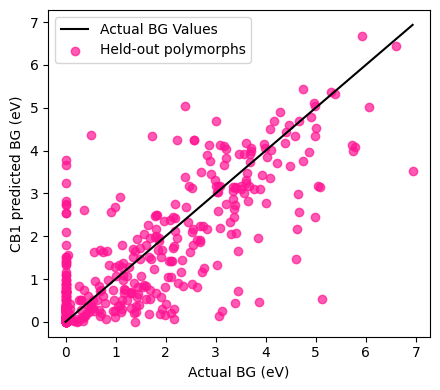

In [25]:
# ============================================================
# CB1 Held-out Polymorph Parity Plot
# ============================================================
import matplotlib.pyplot as plt

y_test_flat = y_test.ravel()
y_actual_heldout = y_test_flat[held_out_mask_test]
y_pred_heldout1 = y_test_pred1[held_out_mask_test]

plt.figure(figsize=(4.5, 4))

lims1 = [min(y_actual_heldout.min(), y_pred_heldout1.min()),
         max(y_actual_heldout.max(), y_pred_heldout1.max())]
plt.plot(lims1, lims1, color='black', label='Actual BG Values')

plt.scatter(y_actual_heldout, y_pred_heldout1, color='deeppink', alpha=0.7,
            label='Held-out polymorphs')

plt.xlabel('Actual BG (eV)')
plt.ylabel('CB1 predicted BG (eV)')
#plt.title('CB1 (Elemental)')
plt.legend()

plt.savefig("CB1_heldout_parity.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

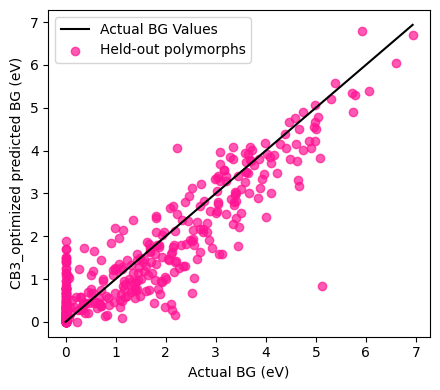

In [26]:
# ============================================================
# CB3 Held-out Polymorph Parity Plot
# ============================================================
import matplotlib.pyplot as plt

y_test_flat = y_test.ravel()
y_actual_heldout = y_test_flat[held_out_mask_test]
y_pred_heldout3 = y_test_pred3[held_out_mask_test]

plt.figure(figsize=(4.5, 4))

lims3 = [min(y_actual_heldout.min(), y_pred_heldout3.min()),
         max(y_actual_heldout.max(), y_pred_heldout3.max())]
plt.plot(lims3, lims3, color='black', label='Actual BG Values')

plt.scatter(y_actual_heldout, y_pred_heldout3, color='deeppink', alpha=0.7,
            label='Held-out polymorphs')

plt.xlabel('Actual BG (eV)')
plt.ylabel('CB3_optimized predicted BG (eV)')
#plt.title('CB3 (Elemental+Geometrical+Structural)')
plt.legend()

plt.savefig("CB3_heldout_parity.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()